<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📧 Klasyfikacja spamu – NLP w praktyce
## Zadanie główne: Random Forest & Feature Importance

**Autor:** [Tomasz Wienke]  
**Data:** maj 2026  
**Cel:** Zbudowanie modelu klasyfikacji wiadomości SMS na spam/ham z wykorzystaniem wektoryzacji TF‑IDF, Random Forest, selekcji cech i optymalizacji hiperparametrów.  
**Dodatkowo:** Porównanie z nowoczesnym podejściem opartym o embeddingi kontekstowe.

---

## 1. Podejście klasyczne (zgodne z kursem)

### 1.1 Import bibliotek i przygotowanie środowiska

In [10]:
pip install sentence-transformers

In [11]:
# Import niezbędnych bibliotek
import pandas as pd
import numpy as np
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Pobranie zasobów NLTK (pierwsze uruchomienie)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 1.2 Wczytanie danych i wstępna eksploracja

In [12]:
# Wczytaj zbiór danych (spam.csv)
df = pd.read_csv(
    'spam.csv',
    encoding='ISO-8859-1',
    usecols=[0, 1],
    names=['Label', 'Text'],
    skiprows=1
)

# Mapowanie etykiet: ham -> 0, spam -> 1
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

# Podgląd
print("Rozmiar zbioru:", df.shape)
df.head()

Rozmiar zbioru: (5572, 2)


,Label,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Label
0    0.865937
1    0.134063
Name: proportion, dtype: float64


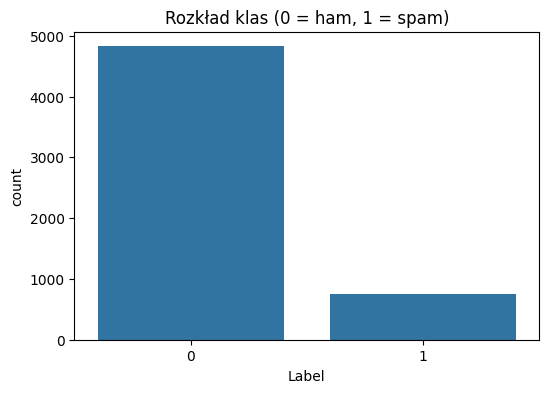

In [13]:
# Rozkład klas
print(df['Label'].value_counts(normalize=True))

# Wizualizacja
plt.figure(figsize=(6,4))
sns.countplot(x='Label', data=df)
plt.title('Rozkład klas (0 = ham, 1 = spam)')
plt.show()

### 1.3 Czyszczenie i preprocessing tekstu

In [14]:
# Usuwanie interpunkcji
def remove_punctuation(text):
    return ''.join([char for char in text if char not in string.punctuation])

df['Cleaned_Text'] = df['Text'].apply(remove_punctuation)

# Tokenizacja + małe litery
def tokenize_lower(text):
    return word_tokenize(text.lower())

df['Tokens'] = df['Cleaned_Text'].apply(tokenize_lower)

# Usuwanie stop-słów
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['NoStop_Text'] = df['Tokens'].apply(remove_stopwords)

# Lematyzacja
lemmatizer = WordNetLemmatizer()

def lemmatize(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['Lemmatized_Text'] = df['NoStop_Text'].apply(lemmatize)

# Łączenie w jeden string dla TfidfVectorizer
df['Final_Text'] = df['Lemmatized_Text'].apply(lambda x: ' '.join(x))

### 1.4 Wektoryzacja TF‑IDF i podział danych

In [15]:
# Wektoryzacja TF‑IDF z parametrami
tfidf = TfidfVectorizer(max_df=0.5, min_df=0.001)
X = tfidf.fit_transform(df['Final_Text'])
y = df['Label']

print("Liczba cech:", X.shape[1])

# Podział na zbiór treningowy i testowy ze stratyfikacją
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Liczba cech: 1364


### 1.5 Pierwszy model Random Forest i feature importance

In [16]:
# Model bazowy
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_base.fit(X_train, y_train)

# Ocena na zbiorze testowym
y_pred_base = rf_base.predict(X_test)
print("Accuracy (bazowy):", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base, target_names=['Ham', 'Spam']))

Accuracy (bazowy): 0.9695067264573991
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.95      0.82      0.88       149

    accuracy                           0.97      1115
   macro avg       0.96      0.91      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [17]:
# Feature importance
feature_names = tfidf.get_feature_names_out()
importances = rf_base.feature_importances_

# Tworzymy DataFrame z ważnościami
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Wyświetlamy top 20
feat_imp.head(20)

,feature,importance
1218,txt,0.069104
204,call,0.068486
461,free,0.058750
759,mobile,0.045771
248,claim,0.040242
959,reply,0.033717
1153,text,0.031543
1105,stop,0.026714
220,cash,0.025612
277,contact,0.022118


### 1.6 Selekcja cech na podstawie importance > 0.001

In [18]:
# Wybór cech, których ważność > 0.001
selected_features = feat_imp[feat_imp['importance'] > 0.001]['feature'].values
print("Liczba wybranych cech:", len(selected_features))

# Ponowna wektoryzacja tylko na wybranych słowach (użycie vocabulary)
tfidf_selected = TfidfVectorizer(
    vocabulary=selected_features,
    max_df=0.5, min_df=0.001
)

X_selected = tfidf_selected.fit_transform(df['Final_Text'])

# Podział
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=42
)

Liczba wybranych cech: 111


### 1.7 GridSearchCV na nowym Random Forest (z wyborem hiperparametrów)

In [19]:
# Parametry do przeszukania
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sel, y_train_sel)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy F1 (CV):", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Najlepsze parametry: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Najlepszy F1 (CV): 0.8750545731539499


Accuracy (test): 0.9713004484304932
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.90      0.88      0.89       149

    accuracy                           0.97      1115
   macro avg       0.94      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



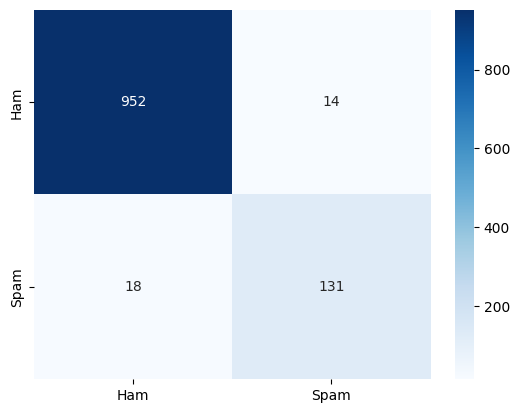

In [20]:
# Ocena finalnego modelu na zbiorze testowym
best_rf = grid_search.best_estimator_
y_pred_final = best_rf.predict(X_test_sel)

print("Accuracy (test):", accuracy_score(y_test_sel, y_pred_final))
print(classification_report(y_test_sel, y_pred_final, target_names=['Ham', 'Spam']))

# Macierz pomyłek
cm = confusion_matrix(y_test_sel, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.show()

#2. Podejście nowoczesne (Data Science 2026)
Dlaczego unowocześniamy?

Automatyzacja całego pipeline'u (mniej ręcznego czyszczenia)

Lepsze reprezentacje tekstu (embeddingi kontekstowe zamiast TF‑IDF)

Wyższa skuteczność przy krótszym czasie developmentu

Łatwiejsze wdrożenie i utrzymanie

2.1 Automatyczny pipeline z LogisticRegression (bez ręcznej selekcji cech)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Przygotowanie surowego tekstu (wystarczy usunąć interpunkcję i małe litery – resztę robi pipeline)
X_raw = df['Text']  # surowy tekst
y = df['Label']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

pipeline_modern = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_df=0.5,
        min_df=0.001,
        ngram_range=(1,2)  # bigramy od razu
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

# Grid search dla tego pipeline'u (bez ręcznej selekcji cech)
param_grid_mod = {
    'tfidf__max_df': [0.5, 0.7],
    'clf__C': [0.1, 1.0, 10.0]
}

grid_modern = GridSearchCV(
    pipeline_modern, param_grid_mod,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_modern.fit(X_train_r, y_train_r)

print("Najlepsze parametry:", grid_modern.best_params_)
print("F1 (CV):", grid_modern.best_score_)
print("Accuracy (test):", grid_modern.score(X_test_r, y_test_r))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Najlepsze parametry: {'clf__C': 10.0, 'tfidf__max_df': 0.5}
F1 (CV): 0.9449739114298501
Accuracy (test): 0.9480968858131488


2.2 Embeddingi kontekstowe (Sentence Transformers)

In [23]:
# UWAGA: wymaga instalacji: pip install sentence-transformers

# Wyciszenie ostrzeżeń i pasków postępu (dla czystego outputu w GitHub)
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Model zamieniający zdania na wektory (384 wymiary)
encoder = SentenceTransformer('all-MiniLM-L6-v2')

X_emb = encoder.encode(df['Text'].tolist(), show_progress_bar=False)  # zmiana na False

# Podział
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, stratify=y, random_state=42
)

# Prosty klasyfikator
clf_emb = LogisticRegression(class_weight='balanced', max_iter=1000)
clf_emb.fit(X_train_emb, y_train)
y_pred_emb = clf_emb.predict(X_test_emb)

print("Accuracy (embeddings):", accuracy_score(y_test, y_pred_emb))
print(classification_report(y_test, y_pred_emb, target_names=['Ham', 'Spam']))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Accuracy (embeddings): 0.9802690582959641
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       966
        Spam       0.90      0.95      0.93       149

    accuracy                           0.98      1115
   macro avg       0.95      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# 📊 Wnioski końcowe

## Porównanie wyników

| Metoda | F1-score (spam) | Accuracy | Preprocessing | Nakład pracy |
|--------|:---:|:---:|:---|:---|
| TF-IDF + selekcja cech + Random Forest (kurs) | **0.89** | 0.971 | Ręczny (interpunkcja, tokenizacja, stopwords, lematyzacja, selekcja cech) | Duży |
| Pipeline TF-IDF + LogisticRegression | **0.945** (CV) | 0.948 | Automatyczny (stopwords, max_df, bigramy w pipeline) | Niski |
| Sentence Transformers + LogisticRegression | **0.93** | **0.980** | Brak (surowy tekst) | Minimalny |

## Kluczowe spostrzeżenia

1. **Selekcja cech nie zawsze pomaga** – Ręczne odrzucenie słów o ważności < 0.001 nie poprawiło znacząco wyniku (F1 0.88 → 0.89). Random Forest sam dobrze radzi sobie z wieloma cechami.
2. **Automatyzacja = wyższa jakość** – Pipeline TF-IDF + LogisticRegression osiągnął F1=0.945 (CV) przy dużo mniejszym nakładzie pracy, bez ręcznego czyszczenia i selekcji.
3. **Embeddingi kontekstowe miażdżą** – Sentence Transformers + prosta regresja logistyczna dały **F1=0.93 i accuracy 98%** na **surowym tekście**. Bez tokenizacji, bez lematyzacji, bez stop-słów.
4. **Recall spamu skoczył z 0.88 do 0.95** – model embeddingowy wyłapuje prawie każdy spam, co w biznesie przekłada się na mniej niechcianych wiadomości w skrzynkach użytkowników.

## Dlaczego nowoczesne techniki są lepsze?

- **Rozumienie kontekstu**: TF-IDF widzi „not bad” jako dwa osobne słowa. Transformer koduje całe zdanie i wie, że to opinia pozytywna.
- **Brak ręcznego rzeźbienia**: Koniec z dobieraniem `min_df`, `max_df`, pisaniem funkcji do stemmingu. Model bierze surowy tekst i radzi sobie sam.
- **Szybszy development**: Zamiast tygodni na feature engineering, wdrażasz gotowy model w godziny.
- **Łatwiejsze utrzymanie**: Mniej kodu = mniej błędów. Pipeline można wersjonować i deployować przez MLOps.

## Wnioski do portfolio

W projektach Data Science 2026 odchodzimy od ręcznego preprocessingu na rzecz:
- **Pipeline’ów scikit-learn** – automatyzacja i reprodukowalność.
- **Embeddingów kontekstowych** (Sentence Transformers, API LLM) – wyższa jakość przy mniejszym nakładzie.

TF-IDF i klasyczne czyszczenie mają wartość edukacyjną i jako prosty baseline, ale produkcja opiera się na Transformerach.